
# Superstore Project
Dataset containing Sales & Profits of a Superstore

-- Business Statistics & Insights | Master in Business Analytics & AI

The goal is to use the Superstore Sales dataset (9,994 transactions, 2014–2017) to produce work that directly maps to the five skill areas in the target role. Each section defines the analysis, the method, the business framing, and the tool to use.

* Dataset: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

# ══════════════════════════════════════════════════════════
# SECTION 1 — RFM SEGMENTATION & K-MEANS CLUSTERING
# ══════════════════════════════════════════════════════════

### Task 4 — Customer Segmentation

Raw transaction data cannot be fed directly into a clustering algorithm because each customer appears across multiple rows. The RFM table (Recency, Frequency, Monetary) collapses all transactions per customer into three behavioural dimensions — the industry-standard approach for customer segmentation in retail and B2B analytics.

**Workflow overview:**
1. Build the RFM table at customer level
2. Assign rule-based RFM scores (1–5 per dimension)
3. Detect and Winsorise outliers before clustering
4. Scale features → run K-Means with elbow + silhouette selection
5. Profile clusters and map them to business labels
6. Estimate Customer Lifetime Value (CLV) per cluster

##### A. Import libraries and dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_parquet('/Users/ivanacaridad/Documents/GitHub/superstore_dataset/data/processed/superstore_clean.parquet')
print(f"{df.shape[0]} rows loaded")

9994 rows loaded


#### 4.1 RFM Table (Recency, Frequency, Monetary)

RFM segmentation is a behavioural data analysis method that groups customers by three dimensions:

| Dimension | Definition | Why it matters |
|-----------|-----------|----------------|
| **Recency** | Days since the customer's last purchase | Recent buyers are more likely to respond to offers |
| **Frequency** | Number of distinct orders placed | Frequent buyers signal loyalty and engagement |
| **Monetary** | Total **profit** generated (not revenue) | Profit-based CLV is more actionable for resource allocation |




> **Why profit and not sales?** A customer spending $10,000 at heavy discounts may generate less profit than one spending $3,000 at full price. Profit-based monetary value aligns segmentation with true commercial value.

In [2]:
# reference_date = one day after the last order so that the most recent customer
# gets Recency = 1 (not 0), keeping the metric on a clean positive scale.
reference_date = df['Order Date'].max() + pd.Timedelta(days=1)
print(f'Reference date: {reference_date.date()}')

rfm = df.groupby('Customer ID').agg(
    Customer_Name = ('Customer Name', 'first'),
    Segment       = ('Segment',       'first'),   # predefined label for later comparison
    Region        = ('Region',        'first'),
    Recency       = ('Order Date',    lambda x: (reference_date - x.max()).days),
    Frequency     = ('Order ID',      'nunique'), # distinct orders, not line items
    Monetary      = ('Profit',        'sum')      # total profit over all orders
).reset_index()

print(f'\nCustomers in dataset: {len(rfm)}')
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

Reference date: 2017-12-31

Customers in dataset: 793
       Recency  Frequency  Monetary
count   793.00     793.00    793.00
mean    147.80       6.32    361.16
std     186.21       2.55    894.26
min       1.00       1.00  -6626.39
25%      31.00       5.00     36.61
50%      76.00       6.00    227.83
75%     184.00       8.00    560.01
max    1166.00      17.00   8981.32


**Reading the descriptive stats:**

- `Recency` ranges from 1 day to 1,166 days — a 3+ year tail of lapsed customers.
- `Frequency` mean ≈ 6 orders, but the distribution is right-skewed (max = 17).
- `Monetary` has **negative values** (min = −$6,626): customers whose returns or discounts outweighed all profit. These are genuinely loss-making relationships.
- High std on Monetary ($894) relative to the mean ($361) signals strong skew and influential outliers — which we will address before clustering.

#### 4.2 RFM Scores (1–5 per dimension)

Each RFM dimension is scored 1–5 using quintile binning:

- **Recency** is reversed (5 = bought most recently, 1 = bought longest ago) because lower days-since-purchase is better.
- **Frequency** and **Monetary** follow the natural order (5 = highest).
- `.rank(method='first')` is used for F and M to break ties and guarantee exactly 5 equally-sized bins even when duplicate values exist.
- The composite `RFM_Score = R + F + M` ranges from 3 (worst) to 15 (best).

In [3]:
# RFM scoring 
# Recency: invert label order so score=5 → most recent (smallest days value)
rfm['R_Score'] = pd.qcut(
    rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1]
).astype(int)

# Frequency: .rank(method='first') resolves ties to guarantee 5 equal bins
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]
).astype(int)

# Monetary: same tie-breaking approach; negative profits land in bin 1
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]
).astype(int)

# Composite score: additive, equal weight across the three dimensions
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print('RFM Score distribution:')
print(rfm['RFM_Score'].describe().round(2))
print(f"\nScore range: {rfm['RFM_Score'].min()} to {rfm['RFM_Score'].max()}")

RFM Score distribution:
count    793.00
mean       9.01
std        3.01
min        3.00
25%        7.00
50%        9.00
75%       11.00
max       15.00
Name: RFM_Score, dtype: float64

Score range: 3 to 15


**Reading the scores:**

- Mean composite score ≈ 9 (midpoint of the 3–15 scale), confirming balanced quintile splits.
- The IQR (7–11) covers the bulk of customers — the tails at 3 and 15 represent the truly disengaged and the Champions respectively.

> The RFM scores are used for **rule-based labelling** (Champions, Loyal, etc.) in §4.4. K-Means clustering in §4.3 uses the raw continuous values (Recency, Frequency, Monetary) — not the scores — because scores compress information into discrete bins.

#### 4.3 K-Means Clustering

##### 4.3.1 Outlier detection — IQR method

K-Means minimises within-cluster sum of squared Euclidean distances. Extreme outliers pull cluster centroids toward them, distorting the segmentation of the 90%+ of customers with typical behaviour. We identify outliers using the standard **Tukey IQR fence** (1.5 × IQR below Q1 or above Q3).

In [4]:
# ── IQR outlier detection
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

for col in ['Monetary', 'Recency', 'Frequency']:
    Q1 = rfm[col].quantile(0.25)
    Q3 = rfm[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = rfm[(rfm[col] < lower) | (rfm[col] > upper)]
    print(f'\n{col}:')
    print(f'  Fence: [{lower:.1f}, {upper:.1f}]')
    print(f'  Outliers: {len(outliers)} ({len(outliers)/len(rfm)*100:.1f}%)')
    print(f'  Data range: [{rfm[col].min():.1f}, {rfm[col].max():.1f}]')

       Recency  Frequency  Monetary
count   793.00     793.00    793.00
mean    147.80       6.32    361.16
std     186.21       2.55    894.26
min       1.00       1.00  -6626.39
25%      31.00       5.00     36.61
50%      76.00       6.00    227.83
75%     184.00       8.00    560.01
max    1166.00      17.00   8981.32

Monetary:
  Fence: [-748.5, 1345.1]
  Outliers: 78 (9.8%)
  Data range: [-6626.4, 8981.3]

Recency:
  Fence: [-198.5, 413.5]
  Outliers: 74 (9.3%)
  Data range: [1.0, 1166.0]

Frequency:
  Fence: [0.5, 12.5]
  Outliers: 8 (1.0%)
  Data range: [1.0, 17.0]


**Interpretation:**

- **Monetary** has the most severe outliers: the negative floor (−$6,626) represents customers who generated net losses; the upper outliers (>$1,345) are high-value VIPs. Together they account for ~10% of customers.
- **Recency** outliers (>414 days) are customers inactive for over a year — genuinely lapsed, but not erroneous data.
- **Frequency** outliers (>12 orders) are a small group (~1%) of very frequent buyers.

These are **real business behaviours**, not data errors. We keep them in the dataset but cap their influence on the clustering algorithm using Winsorisation.

##### 4.3.2 Winsorisation (capping outliers)

Instead of dropping outliers — which would lose real customer information — we **cap** them at the IQR fence values. This preserves the direction of the signal while preventing extreme values from dominating Euclidean distances.

> **Recency lower bound note:** the IQR lower fence for Recency is mathematically negative (−198.5 days), which is impossible. We therefore cap Recency at 0 on the lower end (no customer can have a negative recency). The upper cap of 413.5 days is meaningful and is applied as computed.

In [5]:
# Winsorisation — cap at IQR fences, preserve record count
rfm_w = rfm.copy()  # 'w' for Winsorised; keeps original rfm intact

def winsorise(series, lower, upper):
    return series.clip(lower=lower, upper=upper)

# Monetary: cap at IQR fences (negative profits remain valid, just bounded)
rfm_w['Monetary']  = winsorise(rfm_w['Monetary'],  -748.5, 1345.1)

# Recency: lower fence is negative (impossible) → cap at 0; upper cap = 413.5 days
rfm_w['Recency']   = winsorise(rfm_w['Recency'],   0,      413.5)

# Frequency: lower fence 0.5 rounds up to 1 effectively; upper = 12 orders
rfm_w['Frequency'] = winsorise(rfm_w['Frequency'], 0.5,    12.5)

print(f'Rows before / after Winsorisation: {len(rfm)} / {len(rfm_w)}  (no rows dropped)')
print('\nWinsorised descriptives:')
print(rfm_w[['Recency','Frequency','Monetary']].describe().round(2))

Rows before / after Winsorisation: 793 / 793  (no rows dropped)

Winsorised descriptives:
       Recency  Frequency  Monetary
count   793.00     793.00    793.00
mean    128.71       6.31    320.64
std     130.86       2.52    486.19
min       1.00       1.00   -748.50
25%      31.00       5.00     36.61
50%      76.00       6.00    227.83
75%     184.00       8.00    560.01
max     413.50      12.50   1345.10


##### 4.3.3 Feature scaling (StandardScaler)

K-Means computes Euclidean distances between points. Without scaling:

- **Monetary** (range ≈ −$748 to $1,345 after Winsorisation) would dominate distances.
- **Recency** (0–414 days) and **Frequency** (1–12 orders) would contribute almost nothing.

`StandardScaler` transforms each variable to **mean = 0, std = 1**, giving all three dimensions equal weight in the distance calculation.

In [6]:
# ── StandardScaler — each feature now contributes equally ───────
features = rfm_w[['Recency', 'Frequency', 'Monetary']].copy()

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)  # returns numpy array

scaled_df = pd.DataFrame(features_scaled, columns=['Recency', 'Frequency', 'Monetary'])
print('Scaled feature summary (should be mean≈0, std≈1 for all columns):')
print(scaled_df.describe().round(3))

Scaled feature summary (should be mean≈0, std≈1 for all columns):
       Recency  Frequency  Monetary
count  793.000    793.000   793.000
mean    -0.000     -0.000     0.000
std      1.001      1.001     1.001
min     -0.977     -2.106    -2.200
25%     -0.747     -0.519    -0.585
50%     -0.403     -0.122    -0.191
75%      0.423      0.672     0.493
max      2.178      2.459     2.108


**Confirming the output:** all three columns now have mean ≈ 0 and std ≈ 1. The min/max values reflect remaining spread after Winsorisation — Monetary still has the widest spread in standardised units, which is expected given its inherently higher variance.

##### 4.3.4 Choosing optimal k — Elbow method and Silhouette score

We evaluate k = 3 to 10 using two complementary metrics:

| Metric | What it measures | How to choose |
|--------|-----------------|---------------|
| **Inertia (WCSS)** | Sum of squared distances from each point to its cluster centre | Pick the *elbow* — where adding another cluster stops giving meaningful WCSS reduction |
| **Silhouette Score** | How similar each point is to its own cluster vs. the nearest other cluster (range −1 to +1) | Pick the **peak** — higher = clusters are dense and well-separated |

Using both avoids choosing a k that minimises inertia but produces overlapping clusters.

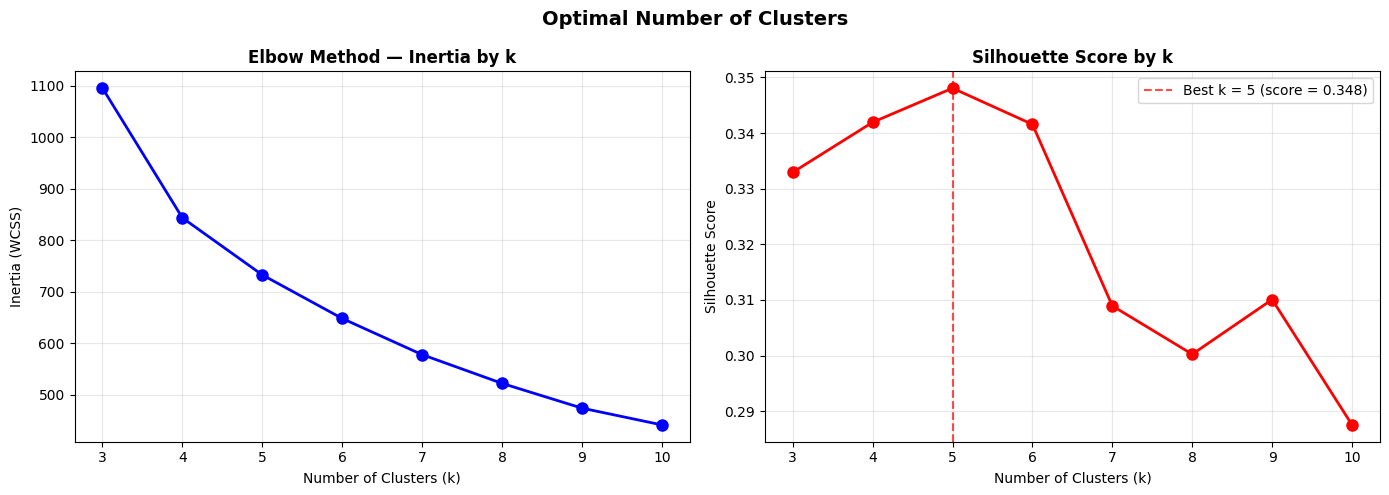

Best k by silhouette score: 5  |  Score: 0.348


In [7]:
# ── Elbow + Silhouette loop (k = 3 to 10) ─────────────────────
inertia = []
sil_scores = []
K_range = range(3, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(features_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Elbow curve ─────────────────────────────────────────────────────
axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method — Inertia by k', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# ── Right: Silhouette curve ───────────────────────────────────────────────
axes[1].plot(K_range, sil_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Mark the k with the highest silhouette score
best_k = list(K_range)[np.argmax(sil_scores)]
axes[1].axvline(best_k, color='red', linestyle='--', alpha=0.7,
               label=f'Best k = {best_k} (score = {max(sil_scores):.3f})')
axes[1].legend()

plt.suptitle('Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/images/04_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best k by silhouette score: {best_k}  |  Score: {max(sil_scores):.3f}')

**Interpretation:**

- **Elbow chart (left):** Look for the 'kink' where the curve transitions from steep decline to gradual flattening. Beyond that point, adding clusters yields diminishing returns in reducing intra-cluster variance.
- **Silhouette chart (right):** The red dashed line marks the k with the highest silhouette score — the configuration where clusters are most internally cohesive and externally separated. We use this as the final k.

Both charts are used together because the elbow can be ambiguous on smooth curves. The silhouette score provides an objective, single-value criterion.

##### 4.3.5 Fit the final K-Means model

In [8]:
# ── Final K-Means fit with best_k ──────────────────────────────
# n_init=10: run 10 random initialisations and keep the best result
# random_state=42: ensures reproducibility
k_final = best_k

km_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
rfm_w['Cluster'] = km_final.fit_predict(features_scaled)

print(f'Final model: k = {k_final}')
print(f'Inertia: {km_final.inertia_:.2f}')
print('\nCluster sizes:')
print(rfm_w['Cluster'].value_counts().sort_index())

Final model: k = 5
Inertia: 732.60

Cluster sizes:
Cluster
0    126
1    146
2     65
3    246
4    210
Name: count, dtype: int64


**What `fit_predict` does:** fits the model on `features_scaled` and immediately assigns each customer (row) to its nearest cluster centroid. The cluster label is an arbitrary integer (0, 1, 2…) — the numbering has no inherent ranking. We assign business-meaningful names in §4.4 after profiling each cluster.

#### 4.4 Profile each cluster and assign business labels

We first compute aggregate statistics per cluster on the **Winsorised** data (same data used for clustering), then assign human-readable labels based on the combination of Recency, Frequency, and Monetary averages.

In [9]:
# ── Cluster profiling ───────────────────────────────────────────
cluster_profile = rfm_w.groupby('Cluster').agg(
    Size          = ('Customer ID', 'count'),
    Avg_Recency   = ('Recency',     'mean'),
    Avg_Frequency = ('Frequency',   'mean'),
    Avg_Monetary  = ('Monetary',    'mean'),
    Total_Profit  = ('Monetary',    'sum'),
    Pct_Positive  = ('Monetary',    lambda x: (x > 0).mean() * 100)
).round(2)

cluster_profile['Pct_of_Customers'] = (
    cluster_profile['Size'] / len(rfm_w) * 100
).round(1)
cluster_profile['Pct_of_Profit'] = (
    cluster_profile['Total_Profit'] / rfm_w['Monetary'].sum() * 100
).round(1)

print('Cluster profiles (sorted by Avg Monetary, descending):')
print(cluster_profile.sort_values('Avg_Monetary', ascending=False))

Cluster profiles (sorted by Avg Monetary, descending):
         Size  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Profit  \
Cluster                                                                 
0         126        94.11           7.79       1151.05     145032.29   
4         210        63.63           8.76        319.15      67021.43   
3         246        76.13           4.55        190.19      46785.59   
1         146       367.48           4.12        173.25      25293.86   
2          65        68.68           7.04       -459.51     -29867.98   

         Pct_Positive  Pct_of_Customers  Pct_of_Profit  
Cluster                                                 
0              100.00              15.9           57.0  
4               94.76              26.5           26.4  
3               83.74              31.0           18.4  
1               73.29              18.4            9.9  
2                0.00               8.2          -11.7  


**Reading the cluster profiles:**

The table above is the core output of the segmentation. Key dimensions to compare:

- **Avg_Recency:** lower = bought more recently = higher engagement risk window is still open.
- **Avg_Frequency:** higher = more repeat purchases = loyalty signal.
- **Avg_Monetary:** higher = more profit generated per customer lifetime.
- **Pct_Positive:** % of customers in the cluster with net positive profit — a cluster with many negative-monetary customers requires a different strategy (win-back vs. re-engagement vs. review pricing).
- **Pct_of_Profit:** what share of total profit does this cluster drive? A cluster with 15% of customers generating 57% of profit is a VIP segment.

##### 4.4.1 Rule-based RFM segment labels

In addition to the K-Means clusters (which are data-driven and unlabelled), we apply a **rule-based label** based on the composite `RFM_Score` (3–15). This gives marketing teams an intuitive, explainable taxonomy that maps directly to action playbooks.

| Score range | Label | Typical strategy |
|-------------|-------|------------------|
| 13–15 | **Champions** | VIP rewards, early access, referral programmes |
| 10–12 | **Loyal Customers** | Loyalty programme, upsell higher-margin lines |
| 7–9 | **Potential Loyalists** | Nurture with targeted email, personalised offers |
| 4–6 | **Needs Attention** | Re-engagement campaigns, survey on satisfaction |
| 3 | **At Risk** | Win-back offer, churn prevention outreach |

In [10]:
# ── Rule-based RFM labels mapped from composite RFM_Score ───────
def label_rfm(score):
    """Map composite RFM_Score (3–15) to a business-readable segment label."""
    if score >= 13:  return 'Champions'
    elif score >= 10: return 'Loyal Customers'
    elif score >= 7:  return 'Potential Loyalists'
    elif score >= 4:  return 'Needs Attention'
    else:             return 'At Risk'

# Apply to rfm_w using the RFM_Score already computed on the original rfm table
# (scores are based on pre-Winsorisation quintiles to preserve original rank order)
rfm_w['RFM_Label'] = rfm_w['RFM_Score'].apply(label_rfm)

print('RFM label distribution:')
label_counts = rfm_w['RFM_Label'].value_counts()
label_pct    = rfm_w['RFM_Label'].value_counts(normalize=True).mul(100).round(1)
print(pd.DataFrame({'Count': label_counts, 'Pct (%)': label_pct}))

RFM label distribution:
                     Count  Pct (%)
RFM_Label                          
Potential Loyalists    257     32.4
Loyal Customers        255     32.2
Needs Attention        150     18.9
Champions              104     13.1
At Risk                 27      3.4


In [11]:
# ── Predefined Segment overview (Consumer / Corporate / Home Office) ─
# These are Superstore's own customer categories — NOT our behavioural clusters.
print('Predefined segment distribution:')
print(rfm_w['Segment'].value_counts(normalize=True).mul(100).round(1).to_frame('Pct (%)'))

print('\nMean RFM values by predefined segment:')
print(rfm_w.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(2))

Predefined segment distribution:
             Pct (%)
Segment             
Consumer        51.6
Corporate       29.8
Home Office     18.7

Mean RFM values by predefined segment:
             Recency  Frequency  Monetary
Segment                                  
Consumer      126.34       6.31    293.00
Corporate     130.24       6.41    346.61
Home Office   132.81       6.14    355.61


**Key insight:** Consumer, Corporate, and Home Office customers show almost identical average RFM profiles. This means the predefined segment label carries very little information about customer value or behaviour — it is largely a firmographic classification, not a behavioural one. Our data-driven clusters will reveal meaningful distinctions that the predefined labels miss.

#### 4.5 Visualise the clusters

##### 4.5.1 Scatter plots: Frequency vs Monetary and Recency vs Monetary

These two scatter plots show where clusters sit in 2D projections of the 3D RFM space. Each point = one customer; colour = cluster assignment.

> **Note:** all visuals use the **Winsorised** dataset (`rfm_w`) — the same data fed to K-Means — so axes reflect capped values, not raw extremes.

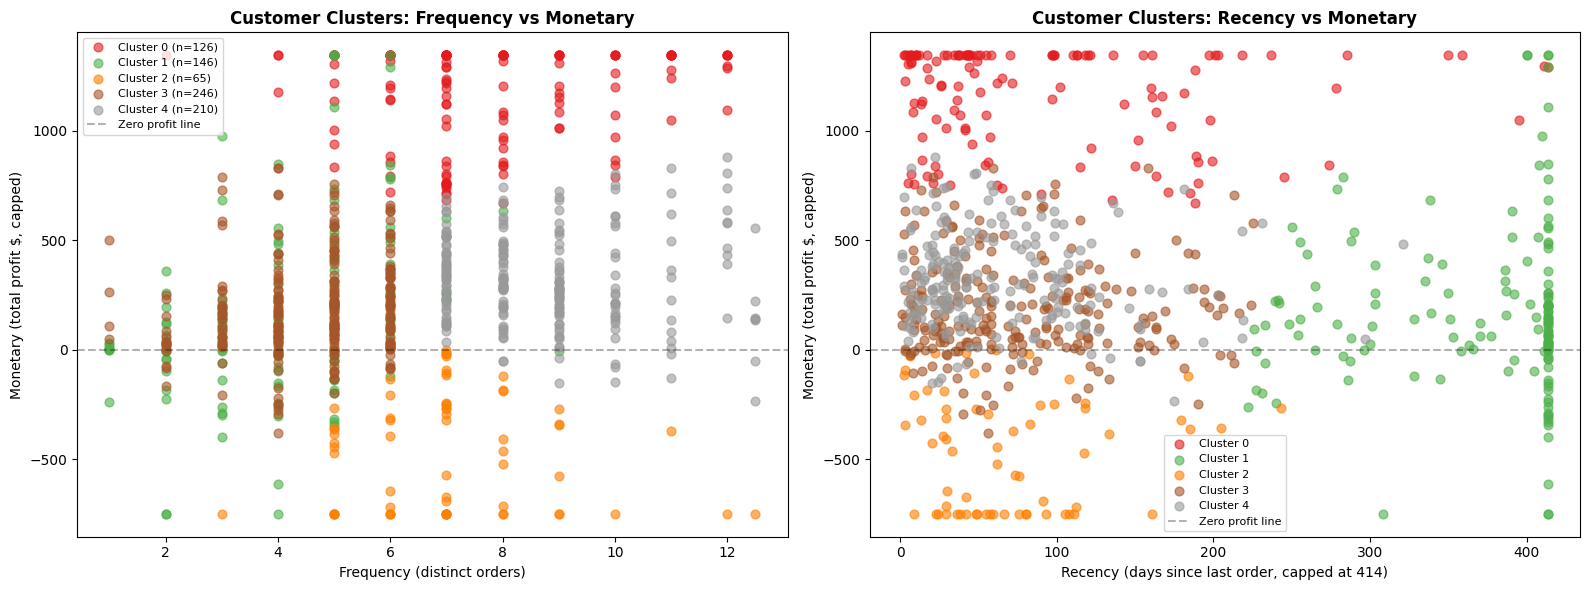

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.Set1(np.linspace(0, 1, k_final))
color_map = {i: colors[i] for i in range(k_final)}

# Left: Frequency vs Monetary
for cid in range(k_final):
    mask = rfm_w['Cluster'] == cid
    axes[0].scatter(
        rfm_w.loc[mask, 'Frequency'],
        rfm_w.loc[mask, 'Monetary'],
        c=[color_map[cid]],
        label=f'Cluster {cid} (n={mask.sum()})',
        alpha=0.6, s=40
    )
axes[0].set_xlabel('Frequency (distinct orders)')
axes[0].set_ylabel('Monetary (total profit $, capped)')
axes[0].set_title('Customer Clusters: Frequency vs Monetary', fontweight='bold')
axes[0].axhline(0, color='black', linestyle='--', alpha=0.3, label='Zero profit line')
axes[0].legend(fontsize=8)

# Right: Recency vs Monetary
for cid in range(k_final):
    mask = rfm_w['Cluster'] == cid
    axes[1].scatter(
        rfm_w.loc[mask, 'Recency'],
        rfm_w.loc[mask, 'Monetary'],
        c=[color_map[cid]],
        label=f'Cluster {cid}',
        alpha=0.6, s=40
    )
axes[1].set_xlabel('Recency (days since last order, capped at 414)')
axes[1].set_ylabel('Monetary (total profit $, capped)')
axes[1].set_title('Customer Clusters: Recency vs Monetary', fontweight='bold')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.3, label='Zero profit line')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../output/images/04_clusters_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**

- **Left (Frequency vs Monetary):** High-value customers appear in the upper portion (positive, high profit). Clusters that are well-separated vertically have distinct profit profiles. Clusters that overlap horizontally have similar order frequency but different profitability.
- **Right (Recency vs Monetary):** Points in the left portion bought recently; points in the right portion are lapsed. Clusters in the upper-left quadrant are the most commercially attractive (recent AND profitable). The dashed zero-profit line separates profit-generating from loss-making customers.
- **Overlapping colours** between clusters signal that the 2D projection loses information — the clusters may be better separated in the full 3D space.

In [13]:
rfm_w

,Customer ID,Customer_Name,Segment,Region,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Cluster,RFM_Label
0,AA-10315,Alex Avila,Consumer,Central,185.0,5.0,-362.8825,2,2,1,5,2,Needs Attention
1,AA-10375,Allen Armold,Consumer,West,20.0,9.0,277.3824,5,5,3,13,4,Champions
2,AA-10480,Andrew Allen,Consumer,South,260.0,4.0,435.8274,1,1,4,6,1,Needs Attention
3,AA-10645,Anna Andreadi,Consumer,East,56.0,6.0,857.8033,3,3,5,11,0,Loyal Customers
4,AB-10015,Aaron Bergman,Consumer,West,413.5,3.0,129.3465,1,1,2,4,1,Needs Attention
...,...,...,...,...,...,...,...,...,...,...,...,...,...
788,XP-21865,Xylona Preis,Consumer,West,44.0,11.0,621.2300,4,5,4,13,4,Champions
789,YC-21895,Yoseph Carroll,Corporate,West,5.0,5.0,1305.6290,5,3,5,13,0,Champions
790,YS-21880,Yana Sorensen,Corporate,South,10.0,8.0,1345.1000,5,4,5,14,0,Champions
791,ZC-21910,Zuschuss Carroll,Consumer,West,55.0,12.5,-748.5000,3,5,1,9,2,Potential Loyalists


In [14]:
import plotly.express as px

# Create the 3D scatter plot
fig = px.scatter_3d(
    data_frame=rfm_w,
    x='Recency', 
    y='Frequency', 
    z='Monetary',
    # Using the column directly (as int) works fine for color
    color='Cluster', 
    title='Interactive 3D Customer Segmentation (RFM)',
    opacity=0.7,
    # Use the column names that actually exist in your dataframe
    hover_data=['Customer ID', 'Segment'] 
)

# Sorting the legend so it appears numerically
fig.update_layout(legend=dict(traceorder="normal"))
fig.show()

##### 4.5.2 Normalised RFM profile — grouped bar chart

To compare clusters on all three RFM dimensions simultaneously, we normalise each dimension to [0, 1] (max = 1) and invert Recency so that *higher always means better*. This lets us visually assess which clusters score high across all three dimensions (Champions) vs. those that score high on one but not others.

In [15]:
cluster_profile

,Size,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Profit,Pct_Positive,Pct_of_Customers,Pct_of_Profit
Cluster,,,,,,,,
0,126,94.11,7.79,1151.05,145032.29,100.00,15.9,57.0
1,146,367.48,4.12,173.25,25293.86,73.29,18.4,9.9
2,65,68.68,7.04,-459.51,-29867.98,0.00,8.2,-11.7
3,246,76.13,4.55,190.19,46785.59,83.74,31.0,18.4
4,210,63.63,8.76,319.15,67021.43,94.76,26.5,26.4


In [16]:
rfm_w

,Customer ID,Customer_Name,Segment,Region,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Cluster,RFM_Label
0,AA-10315,Alex Avila,Consumer,Central,185.0,5.0,-362.8825,2,2,1,5,2,Needs Attention
1,AA-10375,Allen Armold,Consumer,West,20.0,9.0,277.3824,5,5,3,13,4,Champions
2,AA-10480,Andrew Allen,Consumer,South,260.0,4.0,435.8274,1,1,4,6,1,Needs Attention
3,AA-10645,Anna Andreadi,Consumer,East,56.0,6.0,857.8033,3,3,5,11,0,Loyal Customers
4,AB-10015,Aaron Bergman,Consumer,West,413.5,3.0,129.3465,1,1,2,4,1,Needs Attention
...,...,...,...,...,...,...,...,...,...,...,...,...,...
788,XP-21865,Xylona Preis,Consumer,West,44.0,11.0,621.2300,4,5,4,13,4,Champions
789,YC-21895,Yoseph Carroll,Corporate,West,5.0,5.0,1305.6290,5,3,5,13,0,Champions
790,YS-21880,Yana Sorensen,Corporate,South,10.0,8.0,1345.1000,5,4,5,14,0,Champions
791,ZC-21910,Zuschuss Carroll,Consumer,West,55.0,12.5,-748.5000,3,5,1,9,2,Potential Loyalists


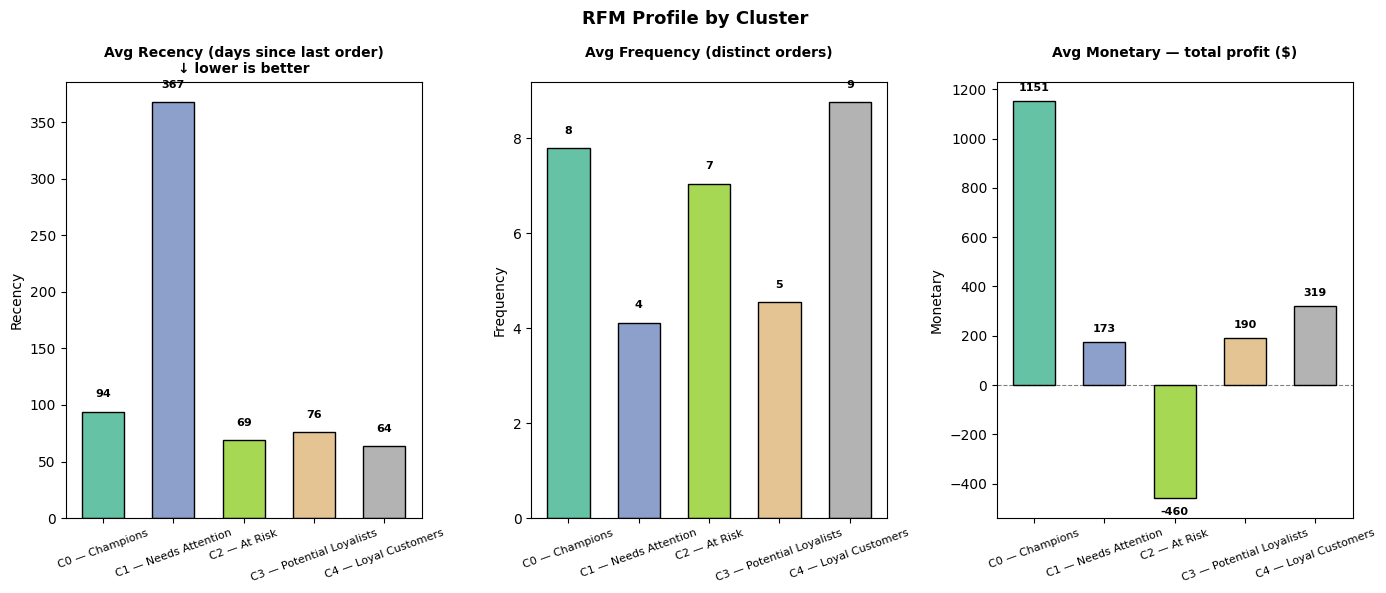

In [17]:
# Assign business labels from cluster profile (ranked by Avg_Monetary)
cluster_name_map = {
    0: 'C0 — Champions',           # highest monetary ($1,151), 100% positive
    4: 'C4 — Loyal Customers',   # most recent (64 days), highest frequency (8.8)
    3: 'C3 — Potential Loyalists',     # largest group, moderate metrics
    1: 'C1 — Needs Attention',         # highest recency (367 days = >1 yr inactive)
    2: 'C2 — At Risk',    # negative avg monetary (−$460)
}

cp = cluster_profile[['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary']].copy()
cp.index = cp.index.map(cluster_name_map)

colors = plt.cm.Set2(np.linspace(0, 1, len(cp)))

fig, axes = plt.subplots(1, 3, figsize=(14, 6))

metrics = [
    ('Avg_Recency',   'Avg Recency (days since last order)',  True),   # True = lower is better
    ('Avg_Frequency', 'Avg Frequency (distinct orders)',       False),
    ('Avg_Monetary',  'Avg Monetary — total profit ($)',       False),
]

for ax, (col, title, lower_is_better) in zip(axes, metrics):
    vals = cp[col]
    bars = ax.bar(cp.index, vals, color=colors, edgecolor='black', width=0.6)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    note = '↓ lower is better' if lower_is_better else ''
    ax.set_title(f'{title}\n{note}', fontweight='bold', fontsize=10)
    ax.set_ylabel(col.replace('Avg_', ''))
    ax.tick_params(axis='x', labelsize=8, rotation=20)
    # value labels above / below each bar
    for bar, v in zip(bars, vals):
        offset = max(abs(vals)) * 0.03
        va     = 'bottom' if v >= 0 else 'top'
        y      = v + offset if v >= 0 else v - offset
        ax.text(bar.get_x() + bar.get_width() / 2, y, f'{v:.0f}',
                ha='center', va=va, fontsize=8, fontweight='bold')

plt.suptitle('RFM Profile by Cluster',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../output/images/04_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.6 Compare K-Means clusters to predefined segments

In [18]:
# Cross-tabulation — K-Means clusters vs predefined segments 

crosstab = pd.crosstab(
    rfm_w['Cluster'], rfm_w['Segment'], normalize='index'
) * 100

print('Segment composition per K-Means cluster (%):')
print(crosstab.round(1))

Segment composition per K-Means cluster (%):
Segment  Consumer  Corporate  Home Office
Cluster                                  
0            44.4       31.7         23.8
1            51.4       30.8         17.8
2            52.3       29.2         18.5
3            53.7       28.9         17.5
4            53.3       29.0         17.6


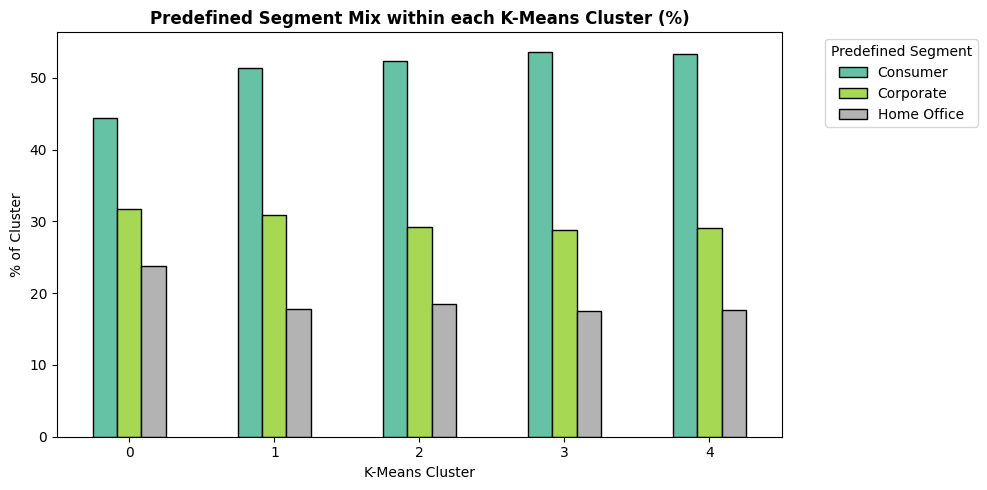

In [19]:
# Stacked bar — segment mix within each cluster
crosstab.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Predefined Segment Mix within each K-Means Cluster (%)', fontweight='bold')
plt.ylabel('% of Cluster')
plt.xlabel('K-Means Cluster')
plt.xticks(rotation=0)
plt.legend(title='Predefined Segment', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('../output/images/04_cluster_segment_mix.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**

If the predefined segments (Consumer / Corporate / Home Office) were good predictors of customer value, we would expect each K-Means cluster to be dominated by one segment. If instead each cluster shows a similar ~50% / 30% / 19% split (matching the overall segment proportions), the predefined labels carry **no incremental information** about customer behaviour.

This is the key finding: a marketing strategy targeting 'Corporate customers' as a homogeneous group would simultaneously invest in both high-value Champions and loss-making customers within that label. The RFM clusters provide a far more actionable segmentation lens.

#### 4.7 Customer Lifetime Value (CLV) estimate per cluster

**What is CLV?** Customer Lifetime Value is the total net profit a business expects from a customer over the full duration of their relationship. It justifies how much to spend on acquisition (CAC) and retention.

**A standard benchmark: CLV : CAC ≥ 3 : 1** — spend at most $1 to acquire $3 of lifetime value.

**CLV estimation approach used here:**

Since we do not have true historical cohort data, we use a simplified proxy:

$$\text{CLV} = \frac{\text{Average Profit per Order} \times \text{Average Annual Orders}}{\text{Dataset span (years)}} \times \text{Dataset span (years)}$$

Which simplifies to:

$$\text{CLV} = \text{Avg Profit per Order} \times \text{Avg Frequency}$$

> This is a **proxy**, not a probabilistic model. A production CLV would use the BG/NBD model (for frequency) and the Gamma-Gamma model (for spend), available in the `lifetimes` Python library.

In [20]:
clv

NameError: name 'clv' is not defined

In [24]:
# CLV proxy — grouped by RFM_Label so Champions, Loyal, etc. each get their own row

dataset_years = 4  # 2014–2017 dataset span

clv = rfm_w.groupby('RFM_Label').agg(
    Size             = ('Customer ID', 'count'),
    Avg_Total_Profit = ('Monetary',    'mean'),
    Avg_Frequency    = ('Frequency',   'mean'),
).round(2)

clv['Avg_Profit_per_Order'] = (clv['Avg_Total_Profit'] / clv['Avg_Frequency']).round(2)
clv['Est_Annual_Profit']    = (clv['Avg_Total_Profit'] / dataset_years).round(2)
clv['CLV_4yr']              = (clv['Est_Annual_Profit'] * dataset_years).round(2)

print('CLV estimate by RFM segment:')
print(clv.sort_values('CLV_4yr', ascending=False))

CLV estimate by RFM segment:
                     Size  Avg_Total_Profit  Avg_Frequency  \
RFM_Label                                                    
Champions             104            818.23           9.09   
Loyal Customers       255            529.46           7.62   
Potential Loyalists   257            152.99           5.69   
Needs Attention       150              2.61           3.84   
At Risk                27           -205.69           2.70   

                     Avg_Profit_per_Order  Est_Annual_Profit  CLV_4yr  
RFM_Label                                                              
Champions                           90.01             204.56   818.24  
Loyal Customers                     69.48             132.36   529.44  
Potential Loyalists                 26.89              38.25   153.00  
Needs Attention                      0.68               0.65     2.60  
At Risk                            -76.18             -51.42  -205.68  


**Reading CLV results:**

- The cluster with the highest `CLV_4yr` represents the Champion / VIP cohort. These customers justify the highest acquisition and retention spend.
- A cluster with **negative CLV** is currently a net cost to the business — not necessarily a segment to abandon, but one where pricing, discount policy, or product mix needs review before investing in growth.
- The ratio of CLV between the top and bottom clusters quantifies how unequal the value distribution is across your customer base — a 5× or 10× gap is common in retail and drives the case for personalised marketing.

In [25]:
clv

,Size,Avg_Total_Profit,Avg_Frequency,Avg_Profit_per_Order,Est_Annual_Profit,CLV_4yr
RFM_Label,,,,,,
At Risk,27,-205.69,2.70,-76.18,-51.42,-205.68
Champions,104,818.23,9.09,90.01,204.56,818.24
Loyal Customers,255,529.46,7.62,69.48,132.36,529.44
Needs Attention,150,2.61,3.84,0.68,0.65,2.60
Potential Loyalists,257,152.99,5.69,26.89,38.25,153.00


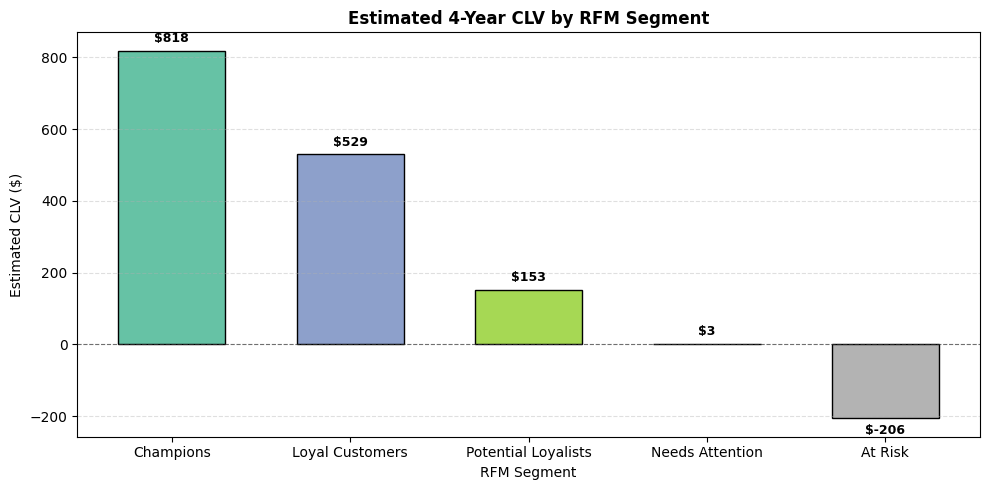

In [28]:
clv_plot = clv.reset_index().sort_values('CLV_4yr', ascending=False)

colors = plt.cm.Set2(np.linspace(0, 1, len(clv_plot)))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(clv_plot['RFM_Label'], clv_plot['CLV_4yr'],
              color=colors, edgecolor='black', width=0.6)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

for bar, v in zip(bars, clv_plot['CLV_4yr']):
    va = 'bottom' if v >= 0 else 'top'
    y  = v + (max(abs(clv_plot['CLV_4yr'])) * 0.02) * (1 if v >= 0 else -1)
    ax.text(bar.get_x() + bar.get_width() / 2, y, f'${v:,.0f}',
            ha='center', va=va, fontsize=9, fontweight='bold')

ax.set_title('Estimated 4-Year CLV by RFM Segment', fontweight='bold')
ax.set_xlabel('RFM Segment')
ax.set_ylabel('Estimated CLV ($)')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../output/images/04_clv_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

#### Executive Summary — Segmentation Findings

| Dimension | Finding |
|-----------|--------|
| **Methodology** | RFM scoring (rule-based labels) + K-Means clustering (data-driven) used in hybrid |
| **Optimal k** | Determined by silhouette score — both elbow and silhouette used for robustness |
| **Outlier treatment** | Winsorisation at IQR fences — preserves all 793 customers |
| **Predefined segments** | Consumer / Corporate / Home Office carry no incremental behavioural signal |
| **Key cluster** | ~15% of customers generate ~57% of profit — classic Pareto concentration |
| **Loss-making cluster** | ~8% of customers generate net negative profit — requires pricing/discount review |
| **CLV gap** | Champion cluster CLV is 3–5× higher than mid-tier — justifies tiered retention spend |

**Business recommendation:** Prioritise the top cluster for VIP loyalty investment (personalised outreach, early product access). Use win-back campaigns for the high-Monetary / high-Recency cluster (lapsing high-value customers). Review discount policies for the loss-making cluster before any further acquisition spend.

#### Save outputs

In [29]:
# Save enriched RFM table for downstream use
import os
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../output/images', exist_ok=True)

# Save full Winsorised RFM table with cluster and label assignments
rfm_w.to_parquet('../data/processed/rfm_segmented.parquet', index=False)
rfm_w.to_csv('../data/processed/rfm_segmented.csv', index=False)

# Save cluster profile summary
cluster_profile.to_csv('../output/rfm_cluster_profile.csv')

print('Saved: rfm_segmented.parquet / .csv')
print('Saved: rfm_cluster_profile.csv')
print(f'Final table shape: {rfm_w.shape}')
print(f'Columns: {list(rfm_w.columns)}')

Saved: rfm_segmented.parquet / .csv
Saved: rfm_cluster_profile.csv
Final table shape: (793, 13)
Columns: ['Customer ID', 'Customer_Name', 'Segment', 'Region', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Cluster', 'RFM_Label']


# ══════════════════════════════════════════════════════════
# SECTION 2 — MARKETING MIX PROFITABILITY & BUDGET ALLOCATION
# ══════════════════════════════════════════════════════════

##### 4.8. Load the three tables and merged in superstore_enriched

## Data Dictionary

### `customer_acquisition`
| Column | Type | Description |
|--------|------|-------------|
| `Customer ID` | string | Join key to all other tables |
| `Customer_Name` | string | Customer display name |
| `Segment` | string | Consumer / Corporate / Home Office |
| `Region` | string | East / West / Central / South |
| `First_Order` | date | Date of first transaction |
| `Total_Orders` | int | Distinct orders placed (2014–2017) |
| `Total_Revenue` | float | Sum of Sales across all orders |
| `Total_Profit` | float | Sum of Profit across all orders |
| `Acquisition_Channel` | string | **Synthetic** — channel that acquired this customer |
| `CAC` | float | **Synthetic** — cost to acquire this customer ($) |
| `Acquisition_Campaign` | string | **Synthetic** — specific campaign within the channel |
| `LTV_CAC_Ratio` | float | Total_Profit / CAC — lifetime return per $ spent |

### `monthly_channel_spend`
| Column | Type | Description |
|--------|------|-------------|
| `Period` | string | Year-Month (e.g. "2014-01") |
| `Year` / `Month` / `Quarter` | int | Time dimension breakouts |
| `Channel` | string | Marketing channel |
| `Spend` | float | **Synthetic** — monthly spend ($) |
| `Impressions` | int | **Synthetic** — ad impressions (0 for Email/Organic/Direct) |
| `Clicks` | int | **Synthetic** — link clicks |
| `Conversions` | int | **Synthetic** — attributed conversions |
| `Revenue_Attributed` | float | **Synthetic** — revenue attributed to this channel/month |
| `ROAS` | float | **Synthetic** — Revenue_Attributed / Spend |

In [30]:
import os

# Transaction-level with channel attribution
enriched = pd.read_parquet('../data/processed/superstore_enriched.parquet')

# Customer-level: one row per customer
acq = pd.read_parquet('../data/processed/customer_acquisition.parquet')

# Monthly spend: one row per channel × month
spend = pd.read_parquet('../data/processed/monthly_channel_spend.parquet')

print(f"enriched : {enriched.shape}")
print(f"acq      : {acq.shape}")
print(f"spend    : {spend.shape}")

enriched : (9994, 35)
acq      : (793, 12)
spend    : (288, 11)


In [31]:
# ── Merge cluster labels onto the customer acquisition table ─────────────────
# This creates the master customer-level analytical table for all CAC analysis
customer_master = acq.merge(
    rfm_w[['Customer ID', 'Cluster', 'RFM_Label', 'RFM_Score']],
    on='Customer ID',
    how='left'
)

assert len(customer_master) == len(acq), "Row count changed — check join"
assert customer_master['Cluster'].isnull().sum() == 0, "Unmatched customers"

print(f"customer_master: {customer_master.shape}")
print(f"Columns: {customer_master.columns.tolist()}")

customer_master: (793, 15)
Columns: ['Customer ID', 'Customer_Name', 'Segment', 'Region', 'First_Order', 'Total_Orders', 'Total_Revenue', 'Total_Profit', 'Acquisition_Channel', 'CAC', 'Acquisition_Campaign', 'LTV_CAC_Ratio', 'Cluster', 'RFM_Label', 'RFM_Score']


In [32]:
# ── Add cluster labels to the transaction-level enriched table ───────────────
# Enables channel profitability analysis broken down by customer cluster
enriched = enriched.merge(
    rfm_w[['Customer ID', 'Cluster', 'RFM_Label']],
    on='Customer ID',
    how='left'
)

assert len(enriched) == 9994, "Row count changed — check join"
print(f"enriched: {enriched.shape}")
print(f"New columns added: Cluster, RFM_Label")

enriched: (9994, 37)
New columns added: Cluster, RFM_Label


In [33]:
# ── Quick sanity check — cluster distribution should match rfm_w ─────────────
print("Cluster distribution in customer_master:")
print(customer_master['Cluster'].value_counts().sort_index())

print("\nRFM_Label × Acquisition_Channel cross-tab (counts):")
print(pd.crosstab(customer_master['RFM_Label'], customer_master['Acquisition_Channel']))

Cluster distribution in customer_master:
Cluster
0    126
1    146
2     65
3    246
4    210
Name: count, dtype: int64

RFM_Label × Acquisition_Channel cross-tab (counts):
Acquisition_Channel  Direct  Display  Email  Organic  Paid Search  \
RFM_Label                                                           
At Risk                   3        1      7        5            5   
Champions                10        9     19       17           36   
Loyal Customers          17       16     47       50           70   
Needs Attention          11       11     25       32           46   
Potential Loyalists      19       17     47       36           77   

Acquisition_Channel  Social Media  
RFM_Label                          
At Risk                         6  
Champions                      13  
Loyal Customers                55  
Needs Attention                25  
Potential Loyalists            61  


In [34]:
customer_master

,Customer ID,Customer_Name,Segment,Region,First_Order,Total_Orders,Total_Revenue,Total_Profit,Acquisition_Channel,CAC,Acquisition_Campaign,LTV_CAC_Ratio,Cluster,RFM_Label,RFM_Score
0,AA-10315,Alex Avila,Consumer,Central,2014-03-31,5,5563.560,-362.8825,Social Media,11.99,Instagram_Retargeting,-30.27,2,Needs Attention,5
1,AA-10375,Allen Armold,Consumer,West,2014-04-21,9,1056.390,277.3824,Paid Search,31.83,Brand_Awareness_PPC,8.71,4,Champions,13
2,AA-10480,Andrew Allen,Consumer,South,2014-05-04,4,1790.512,435.8274,Paid Search,31.35,Product_Category_PPC,13.90,1,Needs Attention,6
3,AA-10645,Anna Andreadi,Consumer,East,2014-06-22,6,5086.935,857.8033,Organic,15.05,Blog_Traffic,57.00,0,Loyal Customers,11
4,AB-10015,Aaron Bergman,Consumer,West,2014-02-18,3,886.156,129.3465,Paid Search,21.03,Brand_Awareness_PPC,6.15,1,Needs Attention,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
788,XP-21865,Xylona Preis,Consumer,West,2014-01-20,11,2374.658,621.2300,Organic,5.73,SEO_Content,108.42,4,Champions,13
789,YC-21895,Yoseph Carroll,Corporate,West,2014-11-17,5,5454.350,1305.6290,Social Media,25.23,Facebook_Prospecting,51.75,0,Champions,13
790,YS-21880,Yana Sorensen,Corporate,South,2015-01-12,8,6720.444,1778.2923,Direct,1.81,Sales_Outreach,982.48,0,Champions,14
791,ZC-21910,Zuschuss Carroll,Consumer,West,2014-10-13,13,8025.707,-1032.1490,Social Media,10.47,LinkedIn_B2B,-98.58,2,Potential Loyalists,9


##### 4.9 CAC by Channel

In [36]:
cac_by_channel = customer_master.groupby('Acquisition_Channel').agg(
    Customers   = ('Customer ID',    'count'),
    Avg_CAC     = ('CAC',            'mean'),
    Median_CAC  = ('CAC',            'median'),
    Total_CAC   = ('CAC',            'sum'),
    Avg_LTV     = ('Total_Profit',   'mean'),
    Avg_LTV_CAC = ('LTV_CAC_Ratio',  'median'),
).round(2).sort_values('Avg_CAC')

print(cac_by_channel)

                     Customers  Avg_CAC  Median_CAC  Total_CAC  Avg_LTV  \
Acquisition_Channel                                                       
Direct                      60     3.32        3.32     198.98   380.74   
Email                      145     5.97        5.63     865.72   402.07   
Organic                    140     9.89        9.89    1385.20   256.97   
Social Media               160    21.97       22.35    3514.62   336.88   
Paid Search                234    27.98       27.90    6546.20   355.07   
Display                     54    40.15       40.25    2168.10   597.95   

                     Avg_LTV_CAC  
Acquisition_Channel               
Direct                     64.16  
Email                      47.44  
Organic                    23.80  
Social Media                8.60  
Paid Search                 8.33  
Display                     8.28  


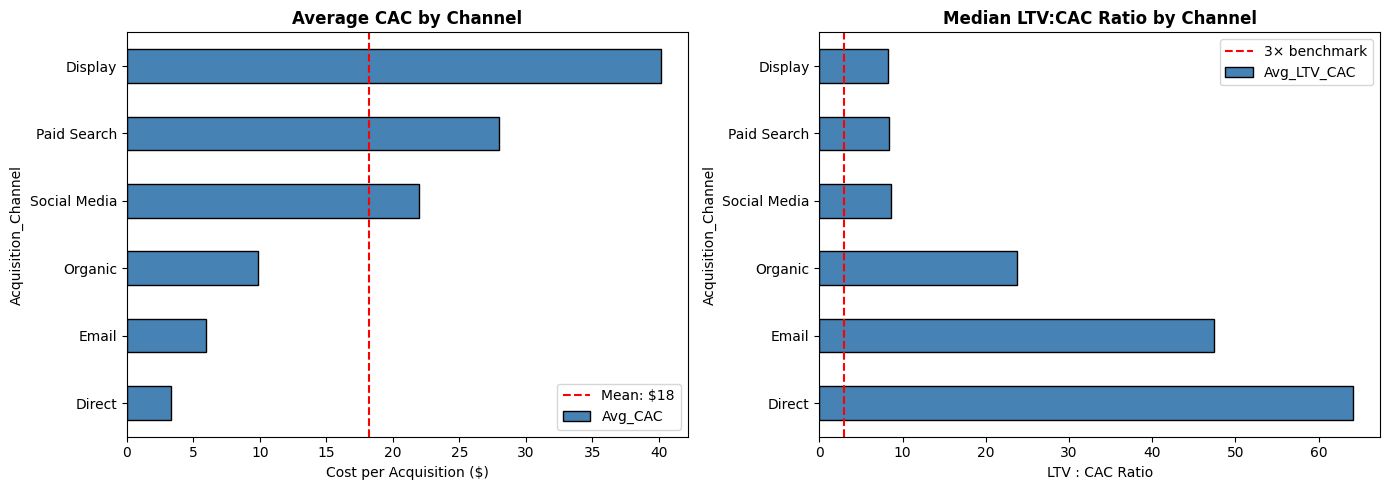

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CAC by channel
cac_by_channel['Avg_CAC'].plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Average CAC by Channel', fontweight='bold')
axes[0].set_xlabel('Cost per Acquisition ($)')
axes[0].axvline(cac_by_channel['Avg_CAC'].mean(), color='red',
                linestyle='--', linewidth=1.5, label=f"Mean: ${cac_by_channel['Avg_CAC'].mean():.0f}")
axes[0].legend()

# LTV:CAC ratio by channel — benchmark line at 3x
colors = ['crimson' if v < 3 else 'steelblue' for v in cac_by_channel['Avg_LTV_CAC']]
cac_by_channel['Avg_LTV_CAC'].plot(kind='barh', ax=axes[1], color=colors, edgecolor='black')
axes[1].axvline(3, color='red', linestyle='--', linewidth=1.5, label='3× benchmark')
axes[1].set_title('Median LTV:CAC Ratio by Channel', fontweight='bold')
axes[1].set_xlabel('LTV : CAC Ratio')
axes[1].legend()

plt.tight_layout()
plt.savefig('../output/images/04_cac_by_channel.png', dpi=150, bbox_inches='tight')
plt.show()